# BasicTask4

6時間サイクルのデータ同化システムを構築する。Kalman Filter（KF）の式を直接解くものでよい。ただし、KFの予報誤差共分散の部分に定数を入れられるように設計しておく。（定数を入れると、３次元変分法と同値である）

In [1]:
# 各種メソッドの定義
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Lorenz96モデルの定義
def L96(x, F):
    """
    Lorenz96モデルの微分方程式を定義する関数
    x: 状態変数の配列
    F: 外部からの強制力
    """
    N = len(x)
    dxdt = np.zeros(N)
    for i in range(N):
        dxdt[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F
    return dxdt
## オイラー法の実装
def euler_step(x, F, dt):
    """
    オイラー法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    dxdt = L96(x, F)
    return x + dxdt * dt
## 4次のルンゲクッタ法の実装
def rk4_step(x, F, dt):
    """
    4次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F) * dt
    k2 = L96(x + 0.5 * k1, F) * dt
    k3 = L96(x + 0.5 * k2, F) * dt
    k4 = L96(x + k3, F) * dt
    return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6

## 2次のルンゲクッタ法の実装
def rk2_step(x, F, dt):
    """
    2次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + dt * k1, F)
    return x + (dt / 2) * (k1 + k2)

## 状態変数の配列のコンストラクタ
class StateArray:
    def __init__(self, N, F, dt, method='rk4'):
        """
        状態変数の配列を初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        method: 使用する時間積分メソッド ('euler', 'rk2', 'rk4')
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.method = method
        self.x = F * np.ones(N)  # 初期状態をFで初期化
        self.x[N // 2-1] *= 1.001  # 中央の値を少し変化させる

    def step(self):
        """
        1ステップの時間積分を実行するメソッド
        """
        if self.method == 'euler':
            self.x = euler_step(self.x, self.F, self.dt)
        elif self.method == 'rk2':
            self.x = rk2_step(self.x, self.F, self.dt)
        elif self.method == 'rk4':
            self.x = rk4_step(self.x, self.F, self.dt)
        else:
            raise ValueError("Unknown method: {}".format(self.method))

# 与えらえたNの個数に基づいて、変数j個×N個のガウシアンノイズをリストで返すメソッド
def generate_gaussian_noise(j=40, N=1000, mean=0.0, std=1.0):
    """
    N個のガウシアンノイズを生成する関数
    N: ノイズの個数
    mean: ノイズの平均値
    std: ノイズの標準偏差
    """
    return [np.random.normal(mean, std, j) for _ in range(N)]


In [2]:
# Extended Kalman Filterクラスの定義
class ExtendedKalmanFilter:
    """
    Extended Kalman Filter for Lorenz96 model
    """
    def __init__(self, N, F, dt, obs_error_std=1.0, forecast_error_std=1.0, use_constant_P=False, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0):
        """
        Extended Kalman Filterの初期化
        
        Parameters:
        -----------
        N : int
            状態変数の数
        F : float
            外部強制力
        dt : float
            時間ステップ
        obs_error_std : float
            観測誤差の標準偏差
        forecast_error_std : float
            予報誤差の標準偏差(定数として使用可能)
        model_error_std : float
            モデル誤差の標準偏差
        use_constant_P : bool
            予報誤差共分散を定数として扱うか(True=3次元変分法と同値)
        method : str
            時間積分メソッド ('euler', 'rk2', 'rk4')
        way : str
            接線線形演算子の計算方法 ('Numerical', 'Mathematical')
        delta : float
            接線線形演算子の数値微分の差分幅(ヤコビ行列計算用)
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.use_constant_P = use_constant_P
        self.method = method
        self.way = way
        self.delta = delta
        self.inflation_factor = inflation_factor

        # StateArrayクラスのインスタンス化
        self.state_array = StateArray(N, F, dt, method=method)
        
        # 観測誤差共分散行列
        self.R = obs_error_std * np.eye(N)
        
        # 予報誤差共分散行列
        self.P_analysis = forecast_error_std * np.eye(N)
        self.P_forecast = None
        self.P_constant = forecast_error_std * np.eye(N)  # 定数として保存
        
        
        # 状態変数の初期化
        self.x_analysis = None
        self.x_forecast = None
        
        # 履歴の保存
        self.analysis_history = []
        self.forecast_history = []
        self.innovation_history = []
        self.P_history = []  # 予報誤差共分散行列の履歴
        
    def initialize_state(self, x0):
        """
        初期状態の設定
        
        Parameters:
        -----------
        x0 : ndarray
            初期状態ベクトル
        """
        self.x_analysis = x0.copy()
        
    def compute_tangent_linear(self, x, way='Numerical'):
        """
        Lorenz96モデルの接線形演算子(ヤコビ行列)を計算
        
        Parameters:
        -----------
        x : ndarray''
            状態ベクトル
            
        Returns:
        --------
        M : ndarray
            接線形演算子行列
        """
        if way == 'Numerical':
            N = len(x)
            M = np.zeros((N, N))
            e = np.eye(N)
            delta = self.delta
            temp_state = StateArray(N, self.F, self.dt, method=self.method)
            temp_state.x = x.copy()
            temp_state.step()
            f = temp_state.x.copy()
            for i in range(N):
                x_plus = x.copy()
                x_plus += delta * e[:, i]
                temp_state.x = x_plus.copy()
                temp_state.step()
                f_plus = temp_state.x.copy()

                M[:, i] = (f_plus - f) / delta
            
            return M
        
        elif way == 'Mathematical':
            N = len(x)
            M = np.zeros((N, N))
            
            for i in range(N):
                # ∂f_i/∂x_{i-2}
                M[i, i-2] = -x[i-1]
                # ∂f_i/∂x_{i-1}
                M[i, i-1] = x[(i+1)%N] - x[i-2]
                # ∂f_i/∂x_i
                M[i, i] = -1.0
                # ∂f_i/∂x_{i+1}
                M[i, (i+1)%N] = x[i-1]
            
            # 接線形演算子: I + dt*M (1次近似)
            return np.eye(N) + self.dt * M
    
    def forecast(self, steps):
        """
        予報ステップ
        
        Parameters:
        -----------
        steps : int
            時間積分のステップ数
        """

        # StateArrayを使って状態ベクトルの時間積分
        self.state_array.x = self.x_analysis.copy()
        
        for _ in range(steps):
            self.state_array.step()
        
        self.x_forecast = self.state_array.x.copy()
        
        if not self.use_constant_P:
            # 接線形演算子の計算と合成
            x_temp = self.x_analysis.copy()
            
            for _ in range(steps):
                M = self.compute_tangent_linear(x_temp, way=self.way)
                # StateArrayを使って次のステップへ
                temp_state = StateArray(self.N, self.F, self.dt, method=self.method)
                temp_state.x = x_temp.copy()
                temp_state.step()
                x_temp = temp_state.x.copy()
            
            # 予報誤差共分散行列の更新
            self.P_forecast = M @ self.P_analysis @ M.T * self.inflation_factor  # インフレーションを適用
        else:
            # 定数として扱う場合(3次元変分法と同値)
            self.P = self.P_constant.copy()
        
        self.forecast_history.append(self.x_forecast.copy())
        self.P_history.append(self.P_forecast.copy())  # 予報誤差共分散行列を保存
        
    def analysis(self, observation, H=None):
        """
        解析ステップ
        
        Parameters:
        -----------
        observation : ndarray
            観測ベクトル
        H : ndarray, optional
            観測演算子(デフォルトは単位行列=全変数を観測)
        """
        if H is None:
            H = np.eye(self.N)
        
        # カルマンゲインの計算
        HPH = H @ self.P_forecast @ H.T
        K = self.P_forecast @ H.T @ np.linalg.inv(HPH + self.R)

        # イノベーション(観測と予報の差)
        innovation = observation - H @ self.x_forecast
        self.innovation_history.append(innovation.copy())
        
        # 解析値の計算
        self.x_analysis = self.x_forecast + K @ innovation
        
        if not self.use_constant_P:
            # 解析誤差共分散行列の更新
            self.P_analysis = (np.eye(self.N) - K @ H) @ self.P_forecast
        
        self.analysis_history.append(self.x_analysis.copy())
        
    def assimilate(self, observation, steps, H=None):
        """
        1サイクルのデータ同化(予報→解析)
        
        Parameters:
        -----------
        observation : ndarray
            観測ベクトル
        steps : int
            予報の時間積分ステップ数
        H : ndarray, optional
            観測演算子
        """
        self.forecast(steps)
        self.analysis(observation, H)
        
    def get_analysis_array(self):
        """解析値の履歴を配列として取得"""
        return np.array(self.analysis_history)
    
    def get_forecast_array(self):
        """予報値の履歴を配列として取得"""
        return np.array(self.forecast_history)
    
    def get_innovation_array(self):
        """イノベーションの履歴を配列として取得"""
        return np.array(self.innovation_history)
    
    def compute_rmse(self, true_states):
        """
        RMSEを計算
        
        Parameters:
        -----------
        true_states : ndarray
            真値の配列
            
        Returns:
        --------
        rmse_analysis : ndarray
            解析値のRMSE
        rmse_forecast : ndarray
            予報値のRMSE
        """
        analysis_array = self.get_analysis_array()
        forecast_array = self.get_forecast_array()
        
        rmse_analysis = np.sqrt(np.mean((analysis_array - true_states)**2, axis=1))
        rmse_forecast = np.sqrt(np.mean((forecast_array - true_states)**2, axis=1))
        
        return rmse_analysis, rmse_forecast
    
    def get_P_history(self):
        """予報誤差共分散行列の履歴を取得(保存されている場合)"""
        if hasattr(self, 'P_history'):
            return self.P_history
        else:
            return None
    
    def compute_spread(self):
        """
        Spreadを計算(予報誤差共分散行列の対角成分の平方根の平均)
        
        Returns:
        --------
        spread : ndarray
            各サイクルにおけるSpread
        """
        if hasattr(self, 'P_history') and len(self.P_history) > 0:
            spread = np.array([np.sqrt(np.trace(P)/self.N) for P in self.P_history])
            return spread
        else:
            print("Warning: P_history not available. Spread cannot be computed.")
            return None
        

In [ ]:
# observed_states.npyの読み込みとExtended KFの実行

# 観測データの読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む

print(f"観測データの形状: {observed_states.shape}")
print(f"真値データの形状: {true_states.shape}")

# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部強制力
dt = 0.05  # 時間ステップ
assim_interval = 0.05  # データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

print(f"\n=== パラメータ設定 ===")
print(f"状態変数の数: {N}")
print(f"外部強制力: {F}")
print(f"時間ステップ: {dt}")
print(f"同化間隔: {assim_interval} MTU ({steps_per_assim} steps)")

# Extended Kalman Filterの初期化
ekf = ExtendedKalmanFilter(
    N=N,
    F=F,
    dt=dt,
    obs_error_std=1.0,          # 観測誤差の標準偏差
    forecast_error_std=10.0,      # 予報誤差の標準偏差
    use_constant_P=False,         # False=EKF, True=3DVAR相当
    inflation_factor=1.0,      # インフレーションファクター
    method='rk4',                # 時間積分メソッド
    way='Numerical',             # 接線線形演算子の計算方法
    delta=1e-5                   # 数値微分の差分幅
)

# 初期状態の設定(観測値にノイズを加えたもの)
spinup = StateArray(N, F, dt, method='rk4')
steps_per_day = 0.2 / spinup.dt
steps_per_year = 365 * steps_per_day
random_steps = np.random.randint(0, steps_per_year)
print(f"\n=== スピンアップ: {random_steps} ステップ実行 ===")
for _ in range(random_steps):
    spinup.step()
x0 = spinup.x
ekf.initialize_state(x0)

print(f"\n=== データ同化開始 ===")
# データ同化ループ
num_assim = len(observed_states)
# num_assim = 10
for k in range(num_assim):
    # 1サイクルのデータ同化を実行
    ekf.assimilate(observed_states[k], steps_per_assim)
    
    if (k % 20) == 0:
        print(f"同化サイクル {k}/{num_assim} 完了")

print(f"\n=== データ同化完了 ===")

# 結果の取得
analysis_states = ekf.get_analysis_array()
forecast_states = ekf.get_forecast_array()
innovations = ekf.get_innovation_array()

print(f"解析状態の形状: {analysis_states.shape}")
print(f"予報状態の形状: {forecast_states.shape}")
print(f"イノベーションの形状: {innovations.shape}")

# 各サイクルの真値と解析値のRMSEを計算
rmse_analysis, rmse_forecast = ekf.compute_rmse(true_states[:num_assim])
print(f"解析値のRMSE: {rmse_analysis}")
print(f"予報値のRMSE: {rmse_forecast}")

観測データの形状: (1460, 40)
真値データの形状: (1460, 40)

=== パラメータ設定 ===
状態変数の数: 40
外部強制力: 8.0
時間ステップ: 0.05
同化間隔: 0.05 MTU (1 steps)

=== スピンアップ: 773 ステップ実行 ===

=== データ同化開始 ===
同化サイクル 0/1460 完了
同化サイクル 20/1460 完了
同化サイクル 40/1460 完了
同化サイクル 60/1460 完了
同化サイクル 80/1460 完了
同化サイクル 100/1460 完了
同化サイクル 120/1460 完了
同化サイクル 140/1460 完了
同化サイクル 160/1460 完了
同化サイクル 180/1460 完了
同化サイクル 200/1460 完了
同化サイクル 220/1460 完了
同化サイクル 240/1460 完了
同化サイクル 260/1460 完了
同化サイクル 280/1460 完了
同化サイクル 300/1460 完了
同化サイクル 320/1460 完了
同化サイクル 340/1460 完了
同化サイクル 360/1460 完了
同化サイクル 380/1460 完了
同化サイクル 400/1460 完了
同化サイクル 420/1460 完了
同化サイクル 440/1460 完了
同化サイクル 460/1460 完了
同化サイクル 480/1460 完了
同化サイクル 500/1460 完了
同化サイクル 520/1460 完了
同化サイクル 540/1460 完了
同化サイクル 560/1460 完了
同化サイクル 580/1460 完了
同化サイクル 600/1460 完了
同化サイクル 620/1460 完了
同化サイクル 640/1460 完了
同化サイクル 660/1460 完了
同化サイクル 680/1460 完了
同化サイクル 700/1460 完了
同化サイクル 720/1460 完了
同化サイクル 740/1460 完了
同化サイクル 760/1460 完了
同化サイクル 780/1460 完了
同化サイクル 800/1460 完了
同化サイクル 820/1460 完了
同化サイクル 840/1460 完了
同化サイクル 860/1460 完了
同化サイクル

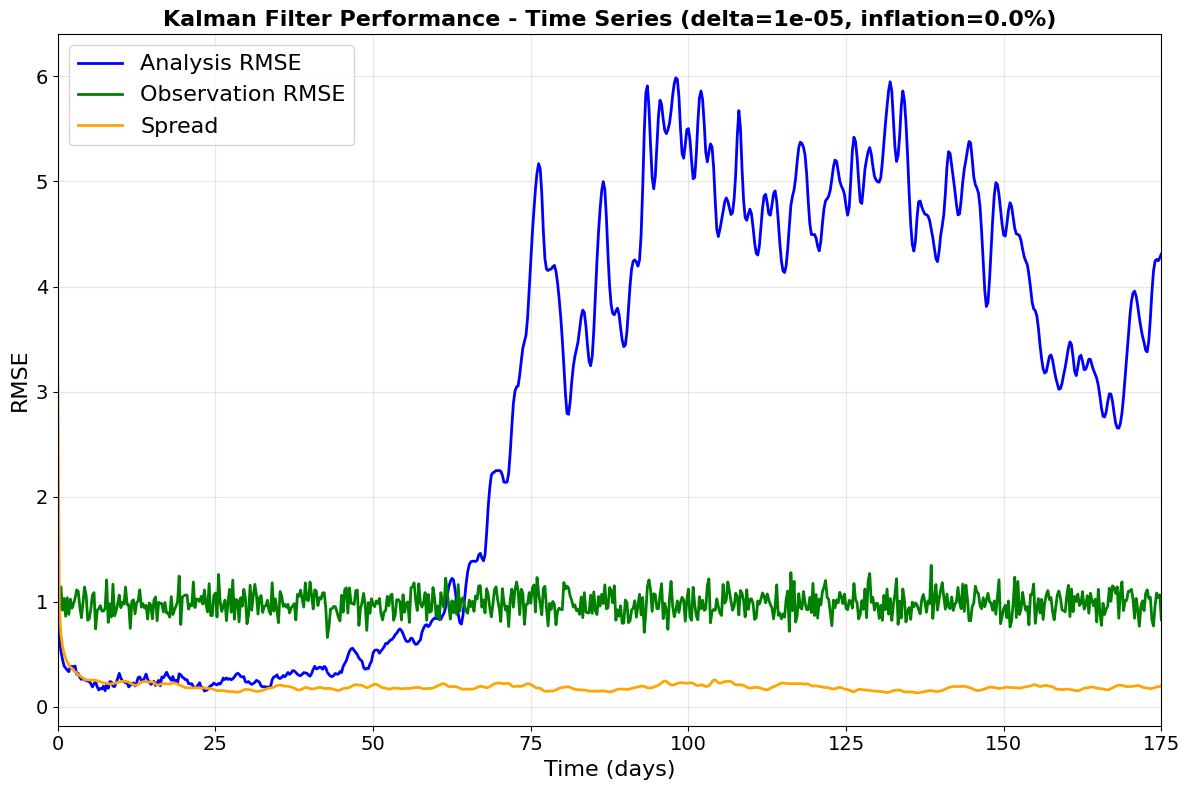

=== RMSE Statistics ===
Analysis - Mean RMSE: 3.6619
Analysis - Std Dev: 1.6824
Analysis - Min RMSE: 0.1513
Analysis - Max RMSE: 6.1006

Forecast - Mean RMSE: 3.7165
Forecast - Std Dev: 1.6892
Forecast - Min RMSE: 0.1592
Forecast - Max RMSE: 6.1829

=== Innovation Statistics ===
Mean Innovation: 0.0158
Innovation Std Dev: 4.2091


In [4]:
# RMSE Evaluation

# Calculate RMSE
rmse_analysis, rmse_forecast = ekf.compute_rmse(true_states)
# Calculate Spread
spread = ekf.compute_spread()
# 観測値の真値に対するRMSEを計算
rmse_observation = np.sqrt(np.mean((observed_states[:len(rmse_forecast)] - true_states[:len(rmse_forecast)])**2, axis=1))

# Visualize RMSE and Spread
fig, axes = plt.subplots(1, 1, figsize=(12, 8))

# RMSE and Spread Time Series
# 日数の配列(4ステップ=1日)
days = np.arange(len(rmse_analysis)) / 4.0
xticks = np.arange(0, days[-1] + 25, 25)
axes.plot(days, rmse_analysis, label='Analysis RMSE', linewidth=2, color='blue')
axes.plot(days, rmse_observation, label='Observation RMSE', linewidth=2, color='green')
axes.plot(days[:len(spread)], spread, label='Spread', linewidth=2, color='orange')
axes.set_xlabel('Time (days)', fontsize=16)
axes.set_ylabel('RMSE', fontsize=16)
axes.set_title(f'Kalman Filter Performance - Time Series (delta={ekf.delta}, inflation={(ekf.inflation_factor-1)*100:.1f}%)', fontsize=16, fontweight='bold')
axes.set_xticks(xticks)
axes.tick_params(axis='both', labelsize=14)
axes.legend(fontsize=16)
axes.grid(True, alpha=0.3)
plt.xlim(0, 175)
plt.tight_layout()
plt.show()
# Display Statistics
print(f"=== RMSE Statistics ===")
print(f"Analysis - Mean RMSE: {np.mean(rmse_analysis):.4f}")
print(f"Analysis - Std Dev: {np.std(rmse_analysis):.4f}")
print(f"Analysis - Min RMSE: {np.min(rmse_analysis):.4f}")
print(f"Analysis - Max RMSE: {np.max(rmse_analysis):.4f}")
print(f"\nForecast - Mean RMSE: {np.mean(rmse_forecast):.4f}")
print(f"Forecast - Std Dev: {np.std(rmse_forecast):.4f}")
print(f"Forecast - Min RMSE: {np.min(rmse_forecast):.4f}")
print(f"Forecast - Max RMSE: {np.max(rmse_forecast):.4f}")

# Innovation Statistics
print(f"\n=== Innovation Statistics ===")
print(f"Mean Innovation: {np.mean(innovations):.4f}")
print(f"Innovation Std Dev: {np.std(innovations):.4f}")

(0.0, 5.0)

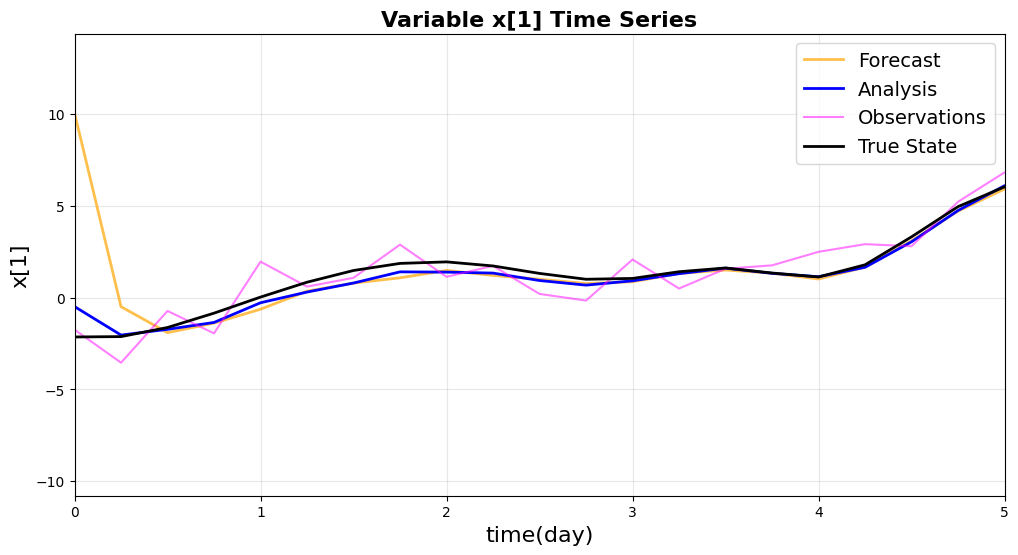

In [5]:
# データ同化の各ステップのある変数のみを可視化
# inflation_factor = [1, 1.03, 1.05]で、0~5, 0~50, 0~300日までの範囲で3*3のグラフで可視化
var_index = 1  # 可視化する変数のインデックス
days = np.arange(len(analysis_states)) / (0.2 / dt)  # 日数の配列
plt.figure(figsize=(12, 6))
plt.plot(days, forecast_states[:, var_index], label='Forecast', color='orange', linewidth=2, alpha=0.7)
plt.plot(days, analysis_states[:, var_index], label='Analysis', color='blue', linewidth=2)
plt.plot(days, observed_states[:, var_index], label='Observations', color='magenta', markersize=4, alpha=0.5)
plt.plot(days, true_states[:, var_index], label='True State', color='black', linewidth=2)

plt.xlabel('time(day)', fontsize=16)
plt.ylabel(f'x[{var_index}]', fontsize=16)
plt.title(f'Variable x[{var_index}] Time Series', fontsize=16, fontweight='bold')
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)


=== Running EKF with inflation factor = 1.0 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460

=== Running EKF with inflation factor = 1.03 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460

=== Running EKF with inflation factor = 1.05 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460

=== Running EKF with inflation factor = 1.1 ===
  Cycle 0/1460
  Cycle 100/1

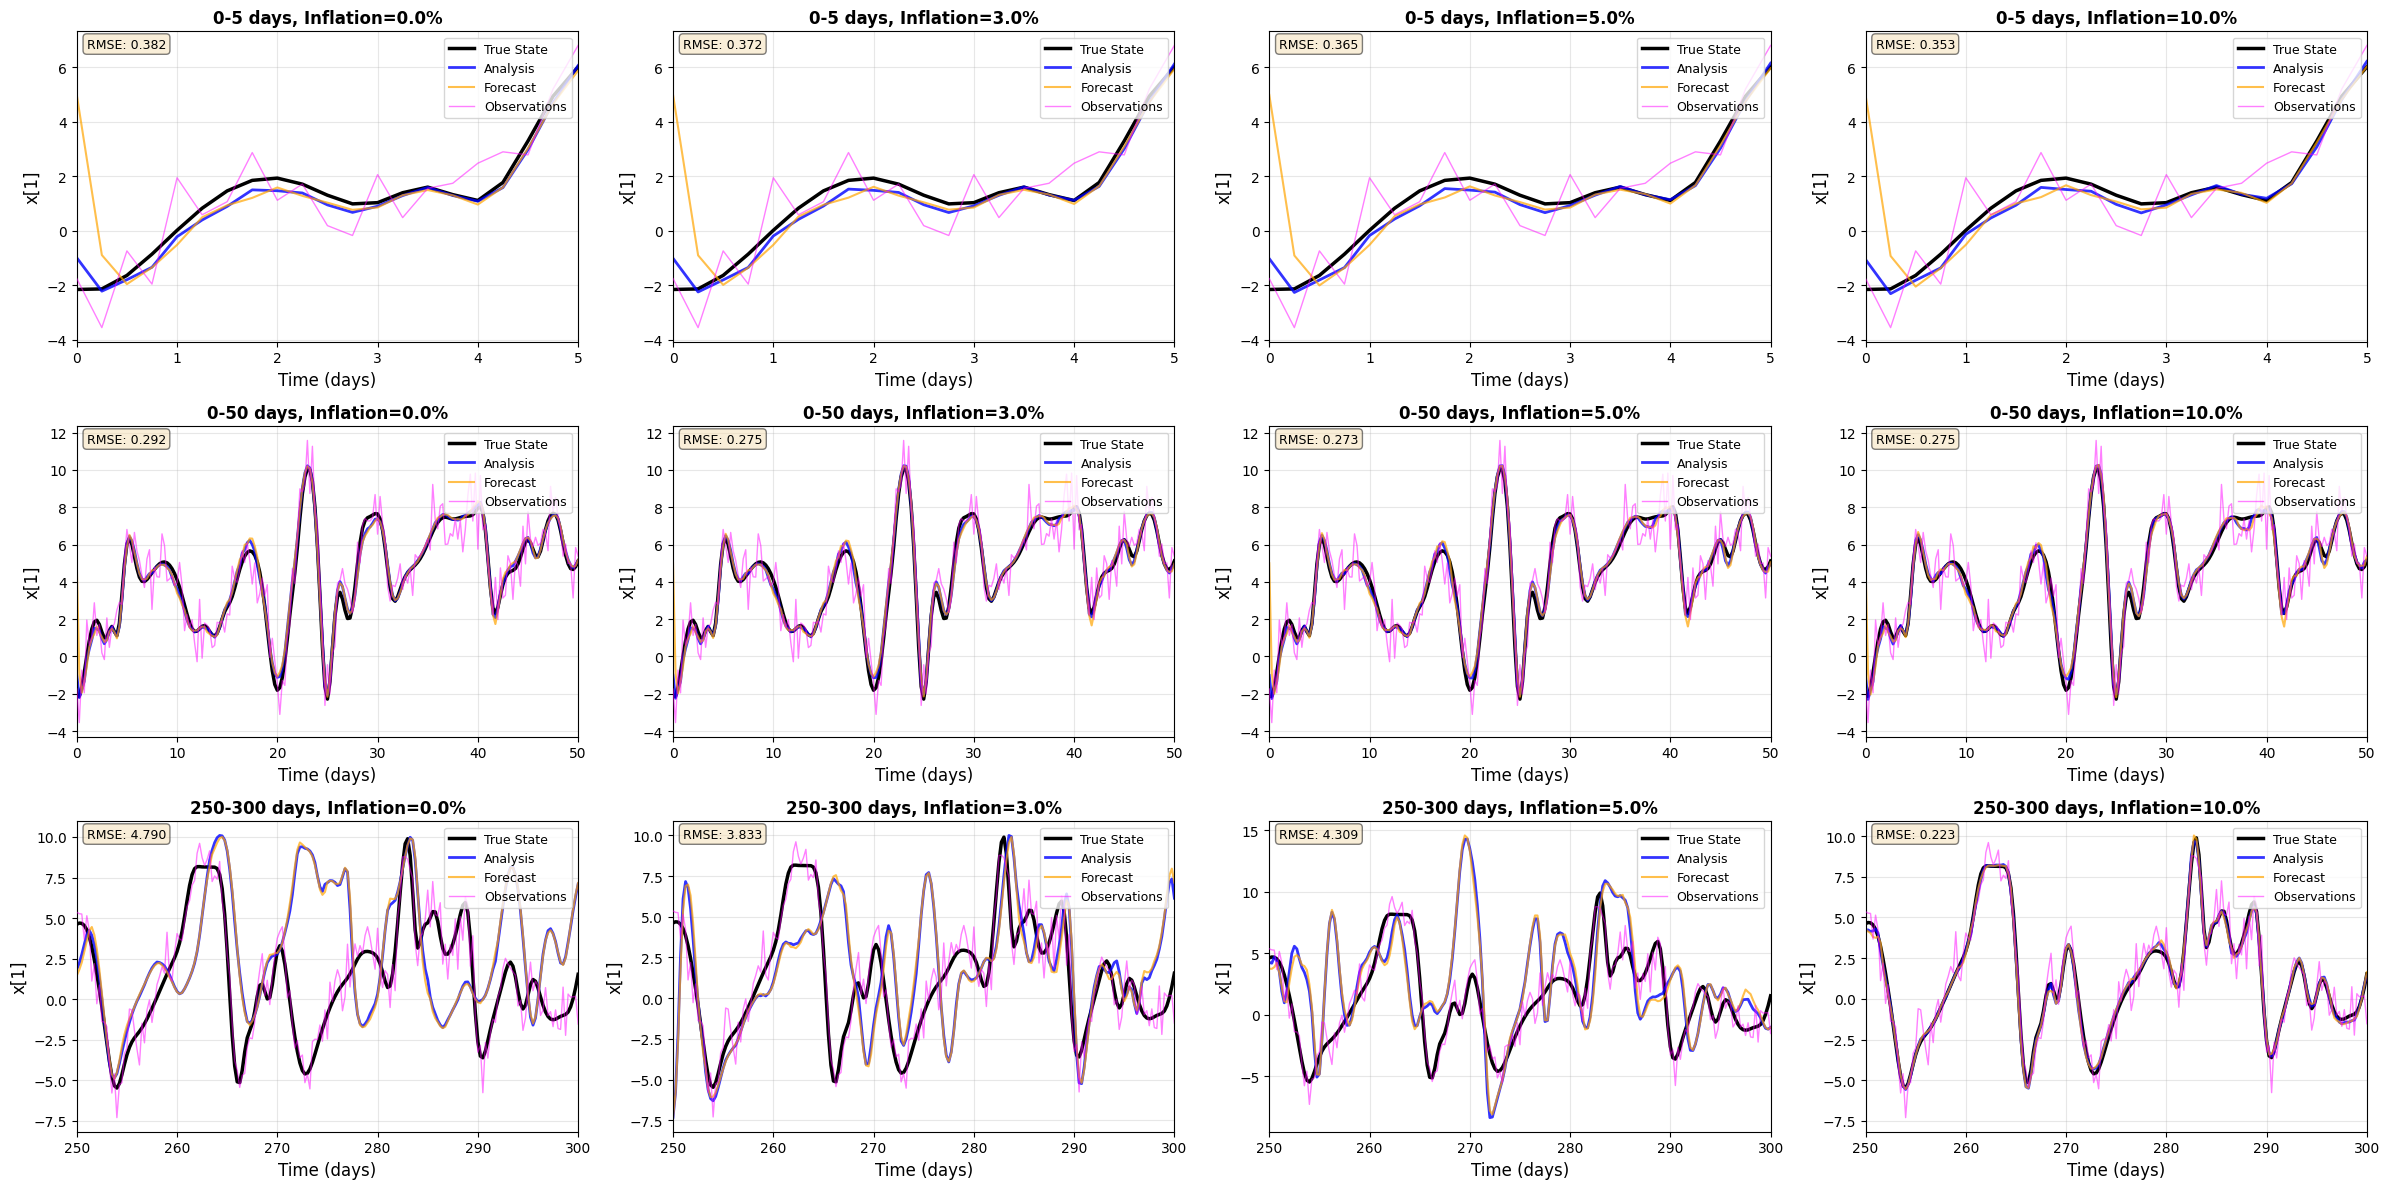


=== Comparison Complete ===
Figure saved to: result/VarianceInfration/inflation_comparison_trajectory_3x4.png


In [6]:
# Inflation Factor Comparison: 3x4 Grid Visualization (Variable Trajectory)
# time ranges (rows) × inflation_factor (columns) = [0-5, 0-50, 250-300] days × [1.0, 1.03, 1.05, 1.1]

inflation_factors = [1.0, 1.03, 1.05, 1.1]
time_ranges = [(0, 5), (0, 50), (250, 300)]  # (start_day, end_day)
var_index = 1  # Variable index to visualize

fig, axes = plt.subplots(3, 4, figsize=(24, 12))

# Store results for all inflation factors
results_dict = {}

for i, inflation in enumerate(inflation_factors):
    print(f"\n=== Running EKF with inflation factor = {inflation} ===")
    
    # Initialize EKF with current inflation factor
    ekf_temp = ExtendedKalmanFilter(
        N=N,
        F=F,
        dt=dt,
        obs_error_std=1.0,
        forecast_error_std=10.0,
        use_constant_P=False,
        inflation_factor=inflation,
        method='rk4',
        way='Numerical',
        delta=1e-5
    )
    
    # Initialize state
    spinup = StateArray(N, F, dt, method='rk4')
    np.random.seed(42)  # For reproducibility
    random_steps = np.random.randint(0, int(365 * 0.2 / dt))
    for _ in range(random_steps):
        spinup.step()
    ekf_temp.initialize_state(spinup.x)
    
    # Run data assimilation
    num_assim = len(observed_states)
    for k in range(num_assim):
        ekf_temp.assimilate(observed_states[k], steps_per_assim)
        if (k % 100) == 0:
            print(f"  Cycle {k}/{num_assim}")
    
    # Get results
    analysis_array = ekf_temp.get_analysis_array()
    forecast_array = ekf_temp.get_forecast_array()
    
    # Store results
    results_dict[inflation] = {
        'analysis': analysis_array,
        'forecast': forecast_array
    }

# Time in days
days = np.arange(len(results_dict[inflation_factors[0]]['analysis'])) / 4.0

# Plot: rows = time ranges, columns = inflation factors
for row, (start_day, end_day) in enumerate(time_ranges):
    for col, inflation in enumerate(inflation_factors):
        ax = axes[row, col]
        
        # Get results for this inflation factor
        analysis_array = results_dict[inflation]['analysis']
        forecast_array = results_dict[inflation]['forecast']
        
        # Filter data by time range
        mask = (days >= start_day) & (days <= end_day)
        days_plot = days[mask]
        
        # Plot variable trajectory
        ax.plot(days_plot, true_states[mask, var_index], label='True State', 
                linewidth=2.5, color='black')
        ax.plot(days_plot, analysis_array[mask, var_index], label='Analysis', 
                linewidth=2, color='blue', alpha=0.8)
        ax.plot(days_plot, forecast_array[mask, var_index], label='Forecast', 
                linewidth=1.5, color='orange', alpha=0.7)
        ax.plot(days_plot, observed_states[mask, var_index], label='Observations', 
                linewidth=1, color='magenta', alpha=0.5, zorder=5)

        # Formatting
        ax.set_xlabel('Time (days)', fontsize=12)
        ax.set_ylabel(f'x[{var_index}]', fontsize=12)
        ax.set_title(f'{start_day}-{end_day} days, Inflation={(inflation-1)*100:.1f}%', 
                     fontsize=12, fontweight='bold')
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(start_day, end_day)
        
        # Calculate RMSE for this time range
        rmse_val = np.sqrt(np.mean((analysis_array[mask, var_index] - true_states[mask, var_index])**2))
        ax.text(0.02, 0.98, f'RMSE: {rmse_val:.3f}',
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('result/VarianceInfration/inflation_comparison_trajectory_3x4.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Comparison Complete ===")
print("Figure saved to: result/VarianceInfration/inflation_comparison_trajectory_3x4.png")


=== Running EKF with inflation factor = 1.0 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460

=== Running EKF with inflation factor = 1.03 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460

=== Running EKF with inflation factor = 1.05 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460

=== Running EKF with inflation factor = 1.1 ===
  Cycle 0/1460
  Cycle 100/1

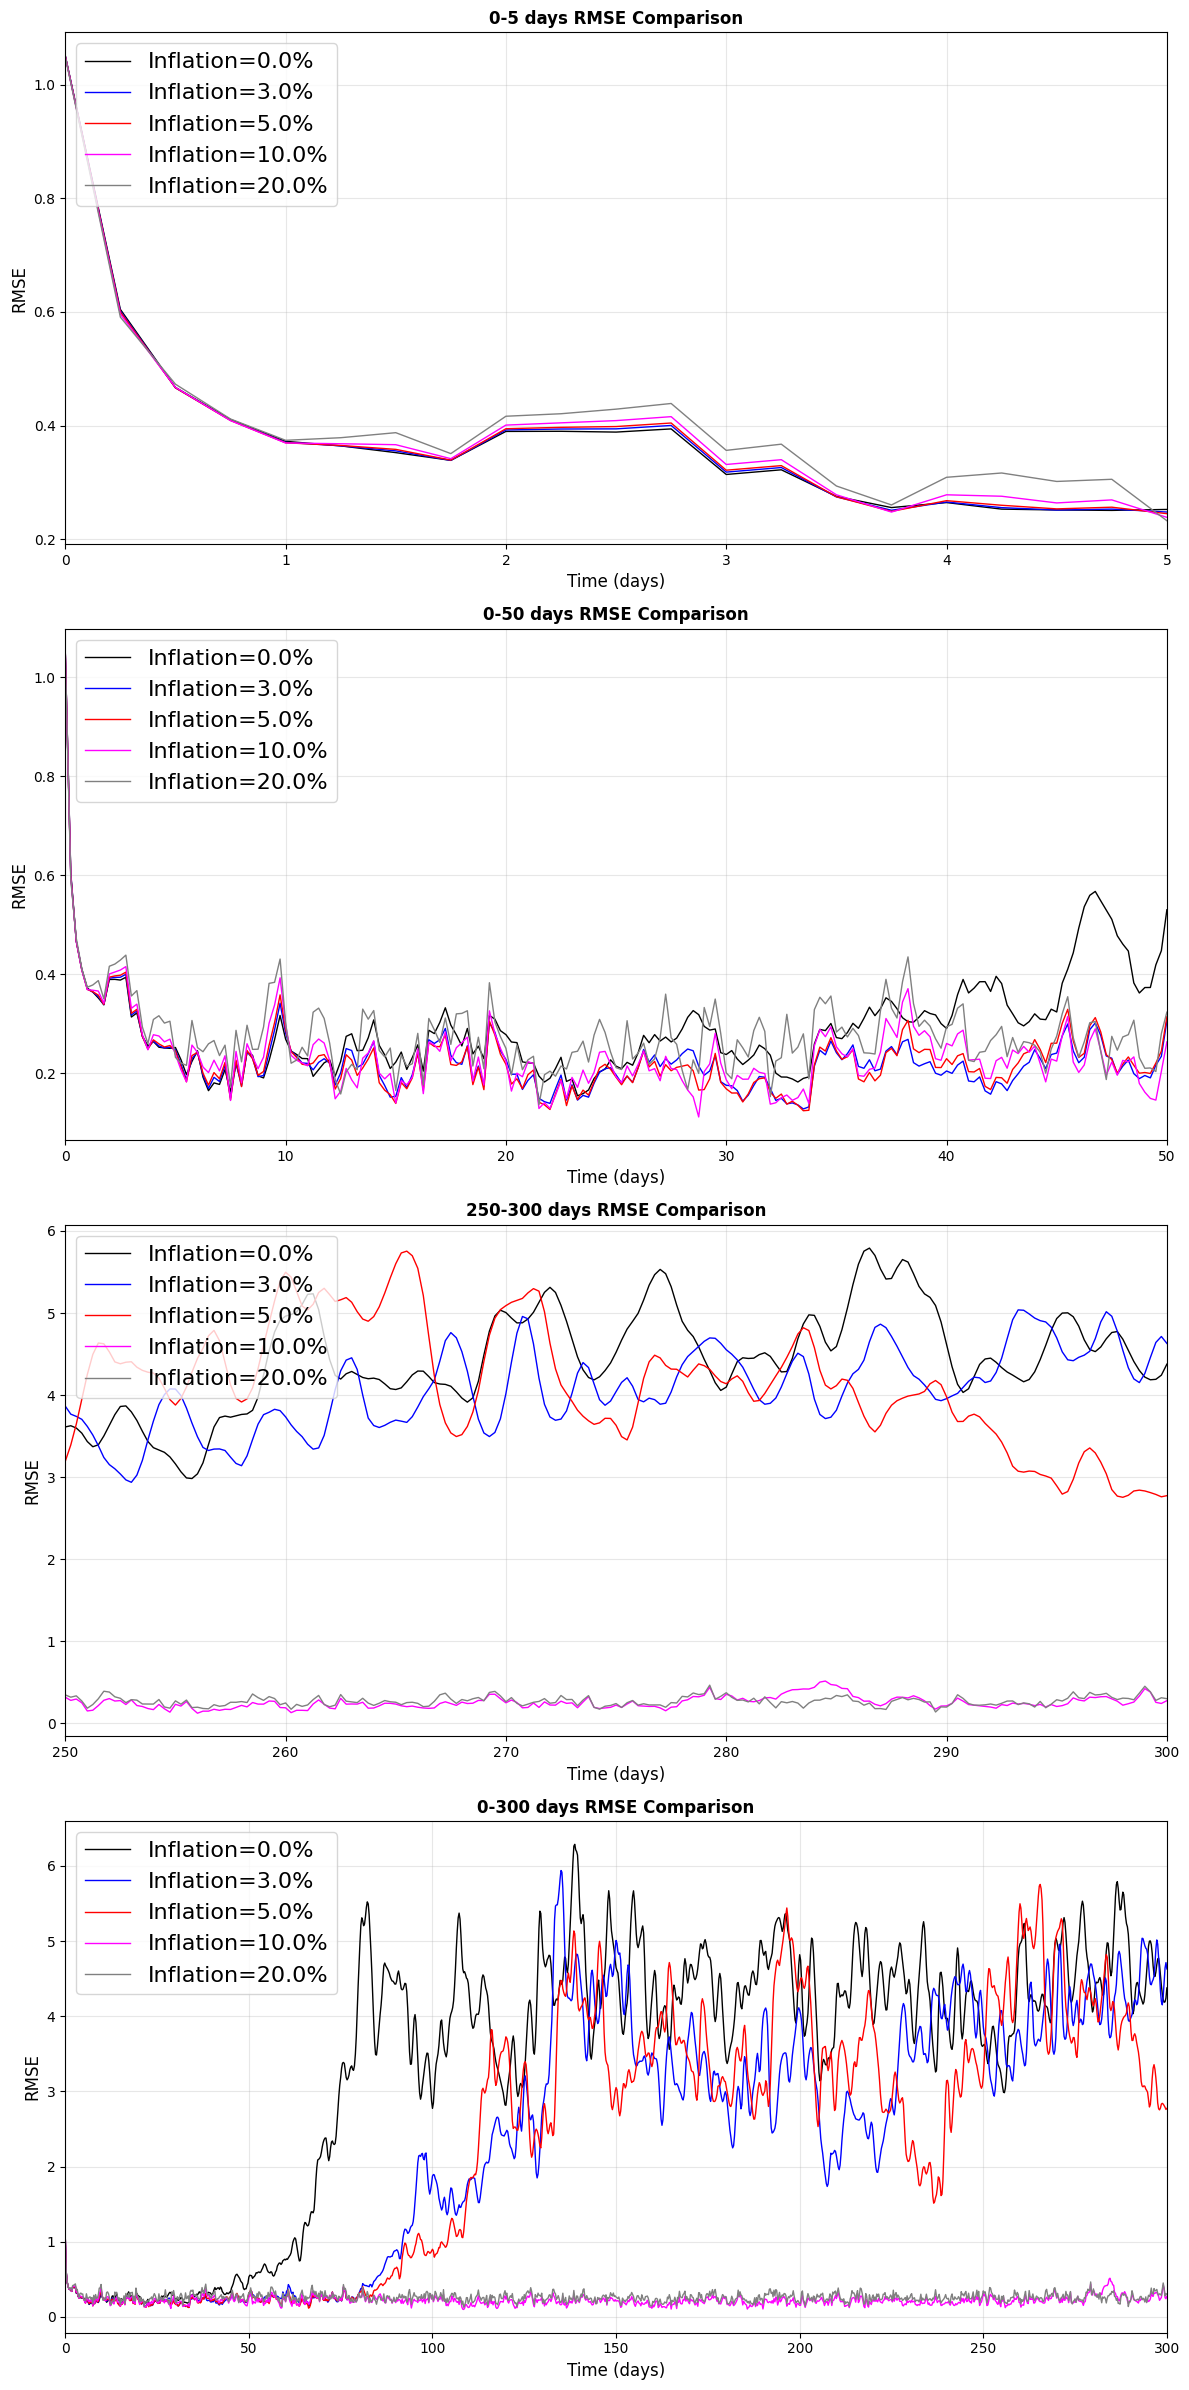


=== Comparison Complete ===
Figure saved to: result/VarianceInfration/inflation_comparison_RMSE.png

=== Average RMSE from Day 10 to Day 300 ===
Inflation Factor 0.0%: Average RMSE = 3.494
Inflation Factor 3.0%: Average RMSE = 2.489
Inflation Factor 5.0%: Average RMSE = 2.456
Inflation Factor 10.0%: Average RMSE = 0.218
Inflation Factor 20.0%: Average RMSE = 0.260


In [11]:

inflation_factors = [1.0, 1.03, 1.05, 1.1, 1.2]
time_ranges = [(0, 5), (0, 50), (250, 300), (0, 300)]  # (start_day, end_day)
cmap = ['black', 'blue', 'red', 'magenta', 'gray']

fig, axes = plt.subplots(4, 1, figsize=(12, 24))

# Store results for all inflation factors
results_dict = {}

for i, inflation in enumerate(inflation_factors):
    print(f"\n=== Running EKF with inflation factor = {inflation} ===")
    
    # Initialize EKF with current inflation factor
    ekf_temp = ExtendedKalmanFilter(
        N=N,
        F=F,
        dt=dt,
        obs_error_std=1.0,
        forecast_error_std=10.0,
        use_constant_P=False,
        inflation_factor=inflation,
        method='rk4',
        way='Numerical',
        delta=1e-5
    )
    
    # Initialize state
    spinup = StateArray(N, F, dt, method='rk4')
    np.random.seed(42)  # For reproducibility
    random_steps = np.random.randint(0, int(365 * 0.2 / dt))
    for _ in range(random_steps):
        spinup.step()
    ekf_temp.initialize_state(spinup.x)
    
    # Run data assimilation
    num_assim = len(observed_states)
    for k in range(num_assim):
        ekf_temp.assimilate(observed_states[k], steps_per_assim)
        if (k % 100) == 0:
            print(f"  Cycle {k}/{num_assim}")
    
    # Get Analysis and Forecast RMSE
    rmse_analysis, rmse_forecast = ekf_temp.compute_rmse(true_states)
    # Store results
    results_dict[inflation] = {
        'analysis': rmse_analysis,
        'forecast': rmse_forecast
    }

# Time in days
days = np.arange(len(results_dict[inflation_factors[0]]['analysis'])) / 4.0

# Plot: rows = time ranges, columns = inflation factors
for row, (start_day, end_day) in enumerate(time_ranges):
    for index, inflation in enumerate(inflation_factors):
        ax = axes[row]
        
        # Get results for this inflation factor
        analysis_rmse = results_dict[inflation]['analysis']
        
        # Filter data by time range
        mask = (days >= start_day) & (days <= end_day)
        days_plot = days[mask]
        
        # Plot variable trajectory
        ax.plot(days_plot, analysis_rmse[mask], label=f'Inflation={(inflation-1)*100:.1f}%', 
                linewidth=1, color=cmap[index])


        # Formatting
        ax.set_xlabel('Time (days)', fontsize=12)
        ax.set_ylabel(f'RMSE', fontsize=12)
        ax.set_title(f'{start_day}-{end_day} days RMSE Comparison', 
                     fontsize=12, fontweight='bold')
        ax.legend(fontsize=16, loc='upper left')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(start_day, end_day)
        
        # # Calculate RMSE for this time range
        # rmse_val = np.sqrt(np.mean((analysis_array[mask, var_index] - true_states[mask, var_index])**2))
        # ax.text(0.02, 0.98, f'RMSE: {rmse_val:.3f}',
        #         transform=ax.transAxes, fontsize=9, verticalalignment='top',
        #         horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('result/VarianceInfration/inflation_comparison_RMSE.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Comparison Complete ===")
print("Figure saved to: result/VarianceInfration/inflation_comparison_RMSE.png")

# calculate Ave RMSE from 10 th day to 300 th day for each inflation factor
print(f"\n=== Average RMSE from Day 10 to Day 300 ===")
for inflation in inflation_factors:
    analysis_rmse = results_dict[inflation]['analysis']
    days = np.arange(len(analysis_rmse)) / 4.0
    mask = (days >= 10) & (days <= 300)
    ave_rmse = np.mean(analysis_rmse[mask])
    print(f"Inflation Factor {(inflation-1)*100:.1f}%: Average RMSE = {ave_rmse:.3f}")


=== Running EKF with inflation factor = 1.0 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460
Inflation Factor 0.0%: Average RMSE from Day 10 to Day 300 = 3.494

=== Running EKF with inflation factor = 1.03 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460
Inflation Factor 3.0%: Average RMSE from Day 10 to Day 300 = 2.489

=== Running EKF with inflation factor = 1.05 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/14

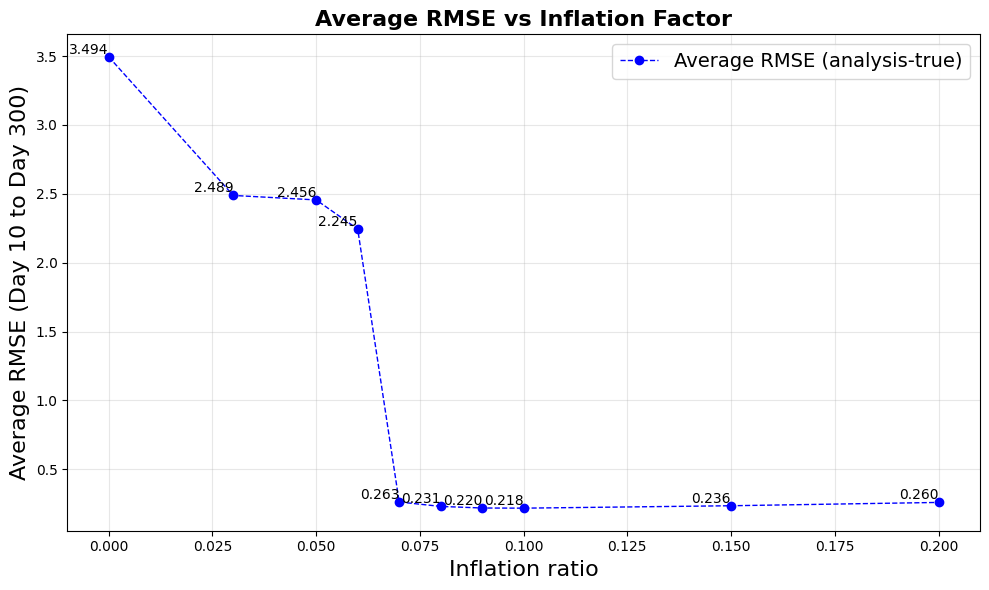

Inflation Factor 0.0%: Average RMSE from Day 10 to Day 300 = 3.494
Inflation Factor 3.0%: Average RMSE from Day 10 to Day 300 = 2.489
Inflation Factor 5.0%: Average RMSE from Day 10 to Day 300 = 2.456
Inflation Factor 6.0%: Average RMSE from Day 10 to Day 300 = 2.245
Inflation Factor 7.0%: Average RMSE from Day 10 to Day 300 = 0.263
Inflation Factor 8.0%: Average RMSE from Day 10 to Day 300 = 0.231
Inflation Factor 9.0%: Average RMSE from Day 10 to Day 300 = 0.220
Inflation Factor 10.0%: Average RMSE from Day 10 to Day 300 = 0.218
Inflation Factor 15.0%: Average RMSE from Day 10 to Day 300 = 0.236
Inflation Factor 20.0%: Average RMSE from Day 10 to Day 300 = 0.260


In [14]:
# Inflation Factor Comparisonによって、10th dayから300th dayまでの平均RMSEがどうなるかを表示
inflation_factors = [1.0, 1.03, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.15, 1.2]
results_dict = {}

for i, inflation in enumerate(inflation_factors):
    print(f"\n=== Running EKF with inflation factor = {inflation} ===")
    
    # Initialize EKF with current inflation factor
    ekf_temp = ExtendedKalmanFilter(
        N=N,
        F=F,
        dt=dt,
        obs_error_std=1.0,
        forecast_error_std=10.0,
        use_constant_P=False,
        inflation_factor=inflation,
        method='rk4',
        way='Numerical',
        delta=1e-5
    )
    
    # Initialize state
    spinup = StateArray(N, F, dt, method='rk4')
    np.random.seed(42)  # For reproducibility
    random_steps = np.random.randint(0, int(365 * 0.2 / dt))
    for _ in range(random_steps):
        spinup.step()
    ekf_temp.initialize_state(spinup.x)
    
    # Run data assimilation
    num_assim = len(observed_states)
    for k in range(num_assim):
        ekf_temp.assimilate(observed_states[k], steps_per_assim)
        if (k % 100) == 0:
            print(f"  Cycle {k}/{num_assim}")
    # Get Analysis RMSE
    rmse_analysis, rmse_forecast = ekf_temp.compute_rmse(true_states)
    # Store results
    results_dict[inflation] = {
        'analysis': rmse_analysis,
        'forecast': rmse_forecast
    }
    # Calculate Average RMSE from Day 10 to Day 300
    days = np.arange(len(rmse_analysis)) / 4.0
    mask = (days >= 10) & (days <= 300)
    ave_rmse = np.mean(rmse_analysis[mask])
    print(f"Inflation Factor {(inflation-1)*100:.1f}%: Average RMSE from Day 10 to Day 300 = {ave_rmse:.3f}")
    results_dict[inflation]['ave_rmse_10_300'] = ave_rmse

# 横軸をInflation Factor (%)、縦軸を10th dayから300th dayまでの平均RMSEとしてプロット
average_rmse_10_300 = [results_dict[inflation]['ave_rmse_10_300'] for inflation in inflation_factors]
inflation_ratio = [(inflation-1) for inflation in inflation_factors]
plt.figure(figsize=(10, 6))
plt.plot(inflation_ratio, average_rmse_10_300, marker='o', linestyle='--', color='blue', linewidth=1, label='Average RMSE (analysis-true)')
plt.xlabel('Inflation ratio', fontsize=16)
plt.ylabel('Average RMSE (Day 10 to Day 300)', fontsize=16)
plt.title('Average RMSE vs Inflation Factor', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(0.025 * np.arange(0, 9))
plt.tight_layout()
plt.legend(loc='upper right', fontsize=14)
for i, inflation in enumerate(inflation_factors):
    plt.text(inflation_ratio[i], average_rmse_10_300[i], f"{average_rmse_10_300[i]:.3f}", fontsize=10,
             verticalalignment='bottom', horizontalalignment='right')   
plt.savefig('result/VarianceInfration/average_RMSE_vs_inflation.png', dpi=150, bbox_inches='tight')
plt.show()

# 結果を表示
for inflation in inflation_factors:
    ave_rmse = results_dict[inflation]['ave_rmse_10_300']
    print(f"Inflation Factor {(inflation-1)*100:.1f}%: Average RMSE from Day 10 to Day 300 = {ave_rmse:.3f}")


=== Running EKF with inflation factor = 1.0 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460

=== Running EKF with inflation factor = 1.03 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460

=== Running EKF with inflation factor = 1.05 ===
  Cycle 0/1460
  Cycle 100/1460
  Cycle 200/1460
  Cycle 300/1460
  Cycle 400/1460
  Cycle 500/1460
  Cycle 600/1460
  Cycle 700/1460
  Cycle 800/1460
  Cycle 900/1460
  Cycle 1000/1460
  Cycle 1100/1460
  Cycle 1200/1460
  Cycle 1300/1460
  Cycle 1400/1460

=== Running EKF with inflation factor = 1.1 ===
  Cycle 0/1460
  Cycle 100/1

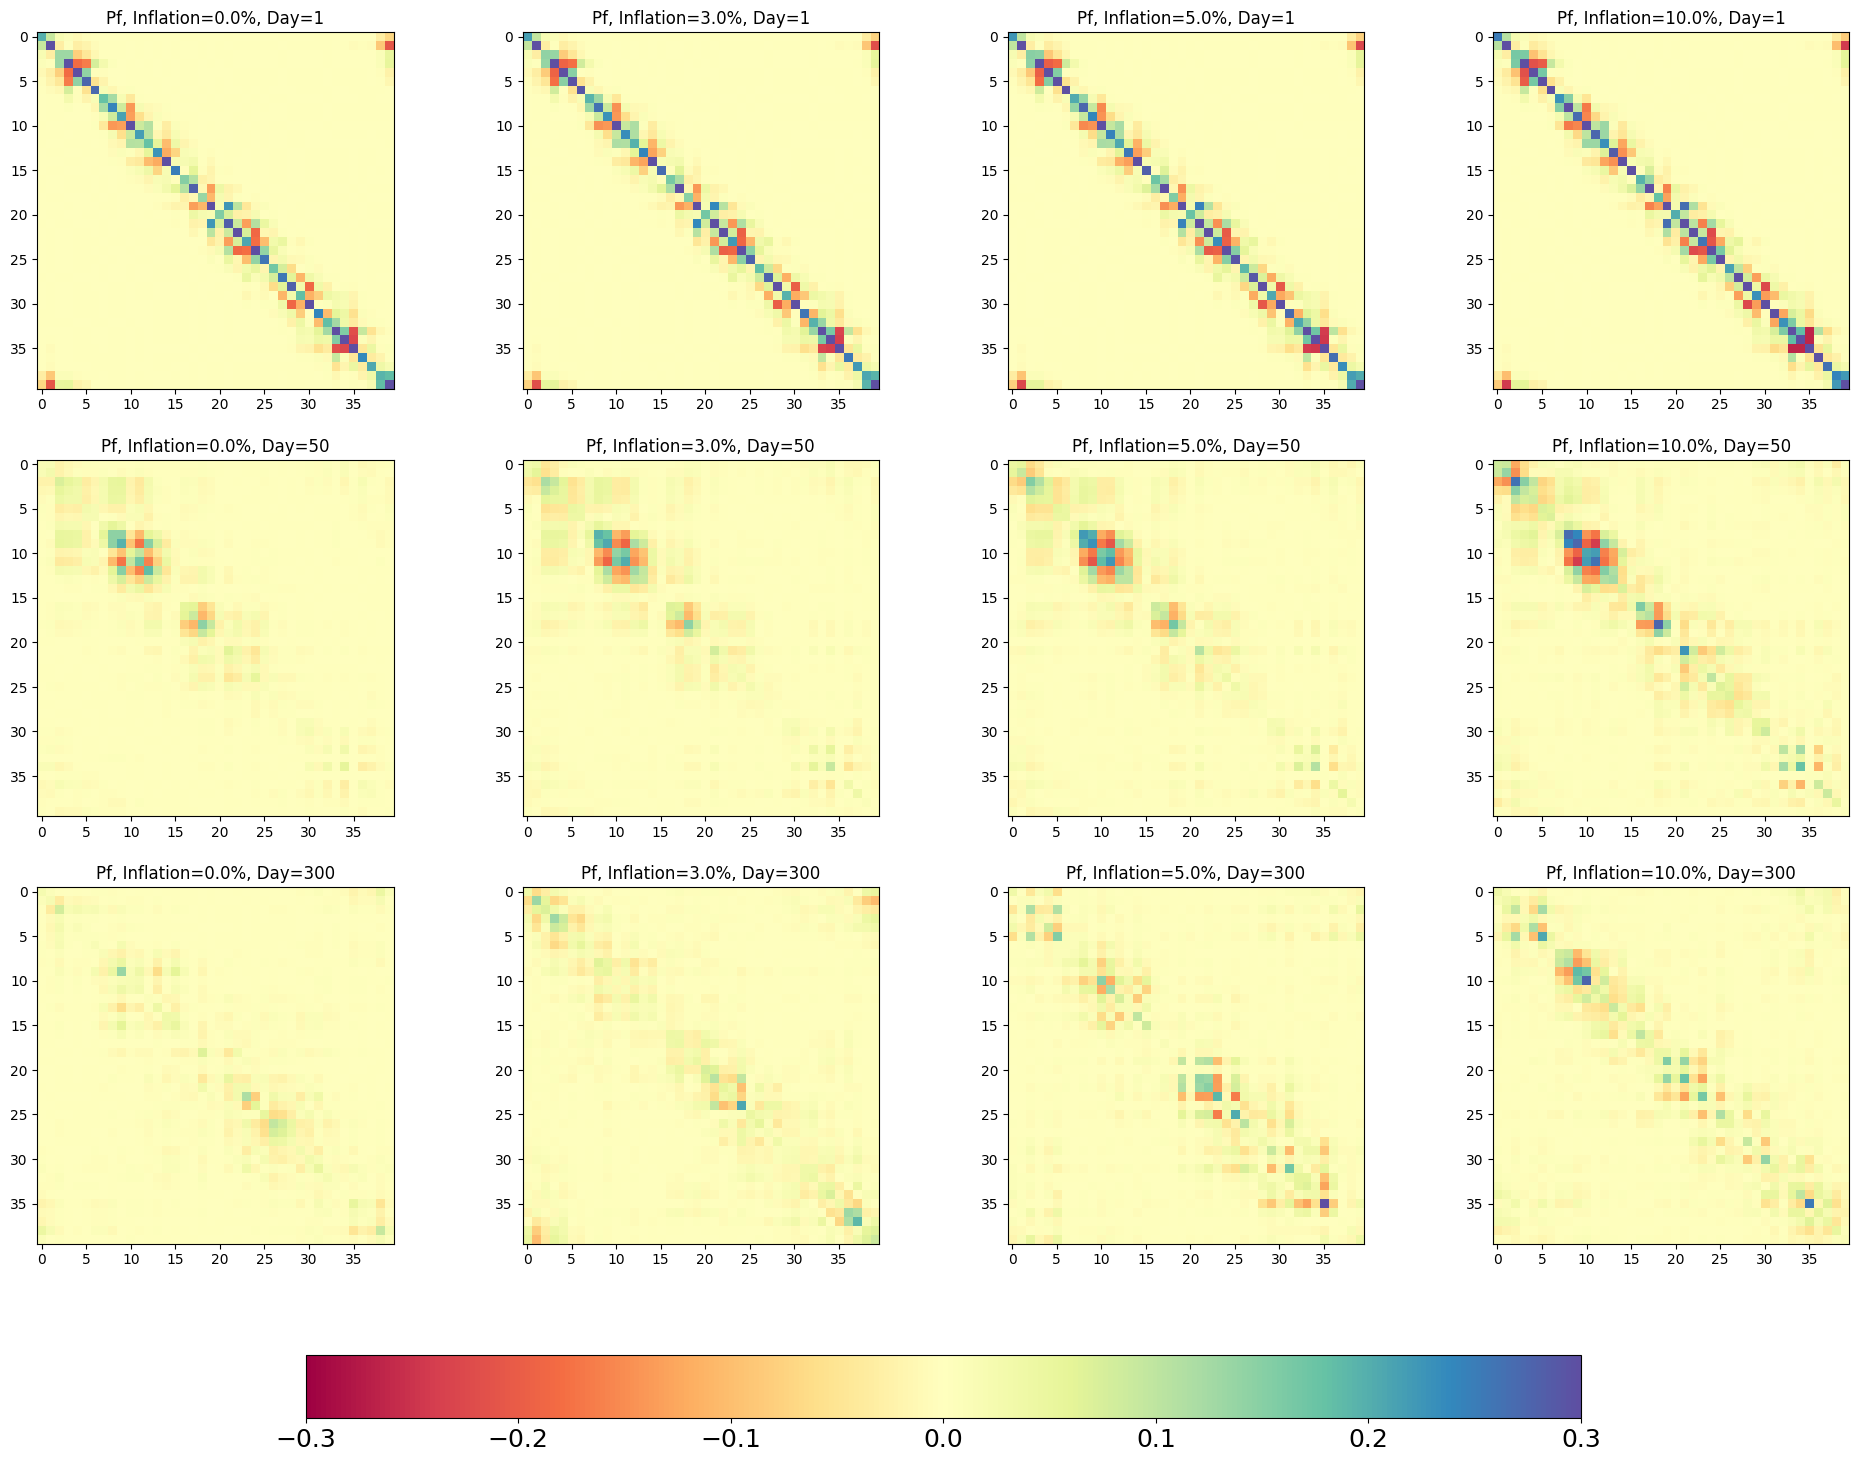


=== Comparison Complete ===


In [20]:
# compare Forecast Error Covariance Matrix P for inflation factor 1.0 and 1.1
inflation_factors = [1.0, 1.03, 1.05, 1.1]
selected_days = [1, 50, 300]  # days to visualize
results_dict = {}
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
for i, inflation in enumerate(inflation_factors):
    print(f"\n=== Running EKF with inflation factor = {inflation} ===")
    
    # Initialize EKF with current inflation factor
    ekf_temp = ExtendedKalmanFilter(
        N=N,
        F=F,
        dt=dt,
        obs_error_std=1.0,
        forecast_error_std=10.0,
        use_constant_P=False,
        inflation_factor=inflation,
        method='rk4',
        way='Numerical',
        delta=1e-5
    )
    
    # Initialize state
    spinup = StateArray(N, F, dt, method='rk4')
    np.random.seed(42)  # For reproducibility
    random_steps = np.random.randint(0, int(365 * 0.2 / dt))
    for _ in range(random_steps):
        spinup.step()
    ekf_temp.initialize_state(spinup.x)
    
    # Run data assimilation
    num_assim = len(observed_states)
    for k in range(num_assim):
        ekf_temp.assimilate(observed_states[k], steps_per_assim)
        if (k % 100) == 0:
            print(f"  Cycle {k}/{num_assim}")
    # Get P history
    P_history = ekf_temp.get_P_history()
    results_dict[inflation] = {
        'P_history': P_history
    }
days = np.arange(len(P_history)) / 4.0  # days array
# Plot Heatmaps of Forecast Error Covariance Matrix P at selected days
for row, day in enumerate(selected_days):
    for col, inflation in enumerate(inflation_factors):
        ax = axes[row, col]
        P_history = results_dict[inflation]['P_history']
        day_index = int(day * 4)  # convert days to index
        P_matrix = P_history[day_index]
        
        im = ax.imshow(P_matrix, cmap='Spectral', vmin=-0.3, vmax=0.3)
        ax.set_title(f'Pf, Inflation={(inflation-1)*100:.1f}%, Day={day}', fontsize=12)
        # ax.set_xlabel('State Index', fontsize=10)
        # ax.set_ylabel('State Index', fontsize=10)
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.046, pad=0.08)
cbar.ax.tick_params(labelsize=18)
plt.savefig('result/VarianceInfration/inflation_comparison_Pf_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n=== Comparison Complete ===")

